# HW2.3: Analyzing Data Directly From S3

Reads the hourly `.parquet` files directly from `s3://dsan6000-<NetID>/wikipedia-hourly/` (no local `data/` folder involved), combines them into one `DataFrame`, and produces two seaborn line plots of hourly event counts.

In [1]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
NETID = "jh2732"
BUCKET_NAME = f"dsan6000-{NETID}"
SOURCE_PREFIX = "wikipedia-hourly"


In [3]:
s3_client = boto3.client("s3")
response = s3_client.list_objects_v2(Bucket=BUCKET_NAME, Prefix=f"{SOURCE_PREFIX}/")
object_keys = [obj["Key"] for obj in response["Contents"] if obj["Key"].endswith(".parquet")]
print(f"Found {len(object_keys)} parquet files in s3://{BUCKET_NAME}/{SOURCE_PREFIX}/")
object_keys


Found 24 parquet files in s3://dsan6000-jh2732/wikipedia-hourly/


['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet',
 'wikipedia-hourly/20260901_070000.parquet',
 'wikipedia-hourly/20260901_080000.parquet',
 'wikipedia-hourly/20260901_090000.parquet',
 'wikipedia-hourly/20260901_100000.parquet',
 'wikipedia-hourly/20260901_110000.parquet',
 'wikipedia-hourly/20260901_120000.parquet',
 'wikipedia-hourly/20260901_130000.parquet',
 'wikipedia-hourly/20260901_140000.parquet',
 'wikipedia-hourly/20260901_150000.parquet',
 'wikipedia-hourly/20260901_160000.parquet',
 'wikipedia-hourly/20260901_170000.parquet',
 'wikipedia-hourly/20260901_180000.parquet',
 'wikipedia-hourly/20260901_190000.parquet',
 'wikipedia-hourly/20260901_200000.parquet',
 'wikipedia-hourly/20260901_210000.parquet',
 'wikipedia-hourly/20260901_220000.parquet',
 'wikipedia-hourly/20260901_230000.parquet',
 'wikipedia-hourly/20260902_000000.parquet',
 'wikipedia-hourly/20260902_010000.parquet',
 'wikipedi

In [4]:
dataframes = [pd.read_parquet(f"s3://{BUCKET_NAME}/{key}") for key in object_keys]
events_df = pd.concat(dataframes, ignore_index=True)
events_df["hour"] = pd.to_datetime(events_df["file_ts_str"], format="%Y%m%d_%H%M%S")

print(events_df.shape)
events_df.head()


(119708, 30)


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str,hour
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000,2026-09-01 04:00:00


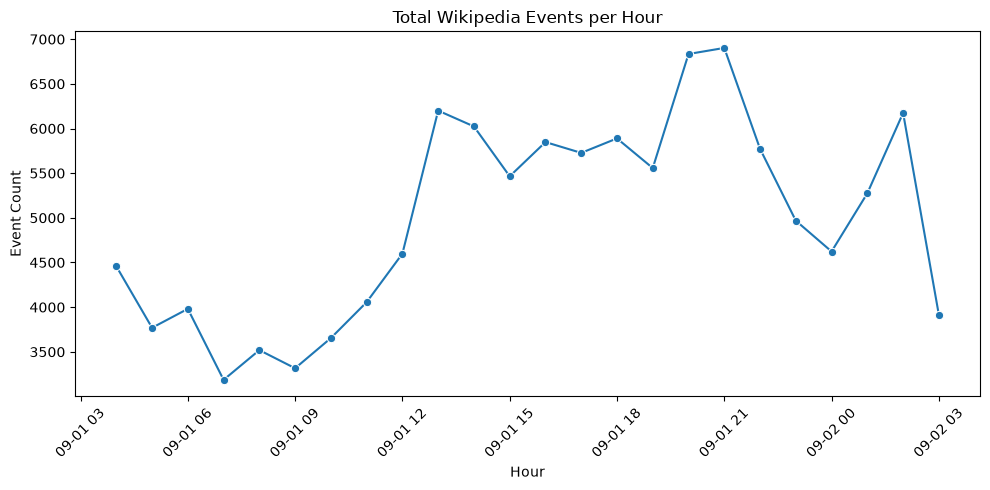

In [5]:
hourly_totals = events_df.groupby("hour").size().reset_index(name="event_count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_totals, x="hour", y="event_count", marker="o")
plt.title("Total Wikipedia Events per Hour")
plt.xlabel("Hour")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")
plt.show()


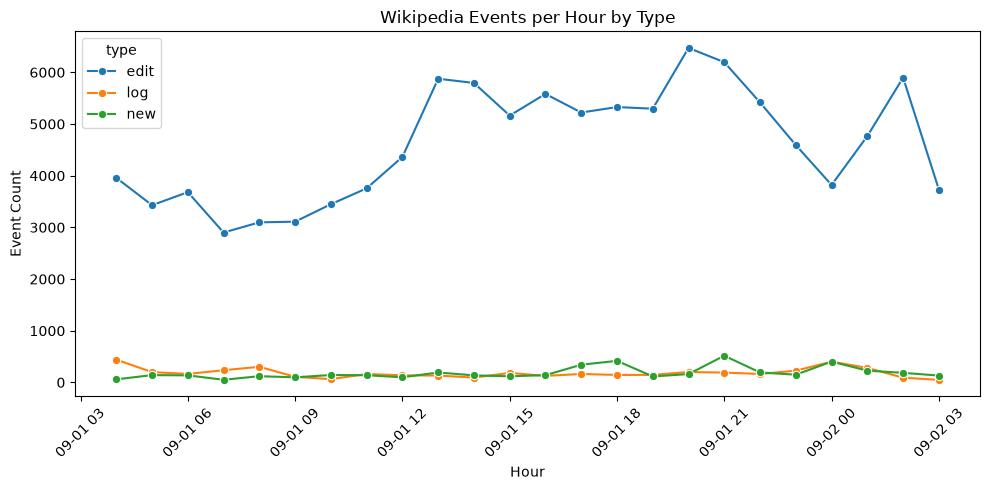

In [6]:
hourly_by_type = events_df.groupby(["hour", "type"]).size().reset_index(name="event_count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_by_type, x="hour", y="event_count", hue="type", marker="o")
plt.title("Wikipedia Events per Hour by Type")
plt.xlabel("Hour")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")
plt.show()
